In [66]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
from diffusionsim import climsim_utils as cut
import torch
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [67]:
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

In [68]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "trial0"
tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id, exp_dir)
base_dir = os.path.join(exp_dir, exp_id)

In [71]:
log_dict = json.load(open(os.path.join(base_dir, f"trial0.json")))
log_dict.keys()



dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'mse_only_losses', 'dist_losses'])

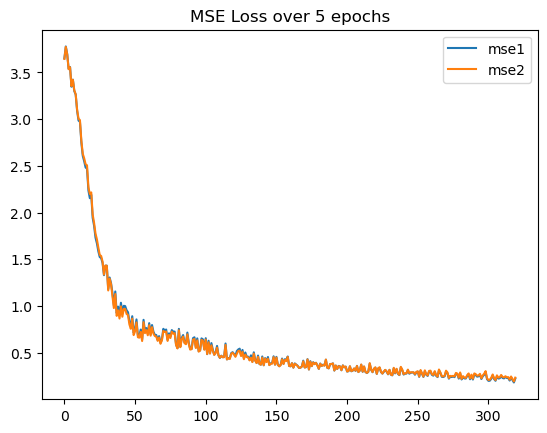

In [77]:
plt.plot(np.array(log_dict['mse_only_losses']['mse']), label='mse1')
plt.plot(np.array(log_dict['dist_losses']['mse']), label='mse2')
plt.title('MSE Loss over 5 epochs')
plt.legend()
plt.show()

In [76]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}

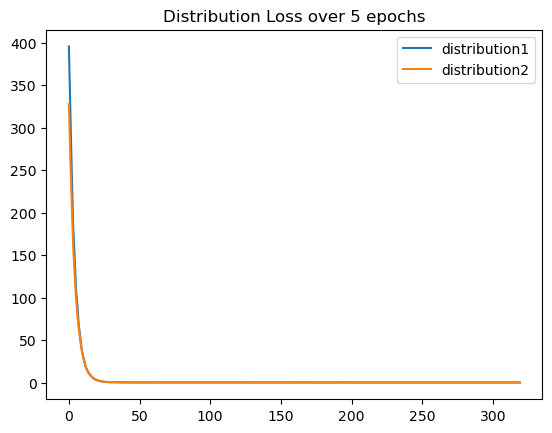

In [75]:
plt.plot(np.array(log_dict['mse_only_losses']['distribution']), label='distribution1')
plt.plot(np.array(log_dict['dist_losses']['distribution']), label='distribution2')
plt.title('Distribution Loss over 5 epochs')
plt.legend()
plt.show()

In [69]:
pprint(dconafig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=12288,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=[36, 210240, 144],
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [9]:
(train_ds, test_ds), (train_indices, test_indices) = data.load_dataset(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [14]:
x, y = train_ds[0]
x.shape, y.shape


(torch.Size([12288, 124]), torch.Size([12288, 128]))

In [46]:
model_mse = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_just_mse.pt"))
model_dist = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_dist_loss.pt"))

model_mse.eval().to(device)
model_dist.eval().to(device)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

## Trying to use data utils
- replicate https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html
- https://github.com/leap-stc/ClimSim/blob/main/preprocessing/create_npy_data_splits.ipynb

Inspired by [Climsim guide](https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html)

In [26]:
dutils = cut.setup_data_utils(dconfig.climsim_type, dconfig.source, dconfig.data_vars, 
                            use_tendencies=dconfig.use_tendencies, data_dir=dconfig.data_dir)

In [29]:
    test_ds.X

<xarray.DataArray 'state_t' (sample: 161280, mli: 124)> Size: 160MB
dask.array<transpose, shape=(161280, 124), dtype=float64, chunksize=(23808, 8), chunktype=numpy.ndarray>
Coordinates:
    lat       (sample) float64 1MB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon       (sample) float64 1MB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
  * mli       (mli) object 992B MultiIndex
  * variable  (mli) <U11 5kB 'state_t' 'state_t' ... 'pbuf_LHFLX' 'pbuf_SHFLX'
  * lev       (mli) object 992B 0 1 2 3 4 5 6 7 ... 56 57 58 59 nan nan nan nan
  * sample    (sample) object 1MB MultiIndex
  * time      (sample) object 1MB 0001-03-02 05:20:00 ... 0001-03-08 01:00:00
  * ncol      (sample) int64 1MB 0 1 2 3 4 5 6 7 ... 377 378 379 380 381 382 383

In [31]:

from dask.diagnostics import ProgressBar
with ProgressBar():
    test_ds.X = test_ds.X.compute()
    test_ds.Y = test_ds.Y.compute()

[########################################] | 100% Completed | 5.35 sms


In [39]:
test_ds.X.data.shape

(161280, 124)

In [80]:
x_test = test_ds.X.data
y_test = test_ds.Y.data

x_test_norm = (x_test - test_ds.xm.numpy()) / test_ds.xs.numpy()
y_test_norm = (y_test - test_ds.ym.numpy()) / test_ds.ys.numpy()

y_mse_test = model_mse(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()
y_dist_test = model_dist(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()

In [81]:
y_test_norm, y_mse_test

(array([[-0.60654589, -0.63565834, -1.20754148, ..., -0.63062456,
         -0.73257194, -0.60943697],
        [-1.04401246, -0.82240929, -1.29353927, ..., -0.63062456,
         -0.73257194, -0.60943697],
        [ 0.42072694,  0.19917645, -0.11957182, ..., -0.63062456,
         -0.73257194, -0.60943697],
        ...,
        [ 1.36678694,  0.46805456, -0.20182888, ..., -0.63062047,
          0.27487803,  0.54659575],
        [ 1.76110789,  1.51138283,  0.6774151 , ...,  1.09071919,
          2.03586621,  1.93033042],
        [ 1.38972985,  2.36698824,  1.57617047, ..., -0.56559484,
          0.60883392,  1.02901249]]),
 array([[-0.01379928, -0.05070778, -0.06511268, ...,  0.12229963,
          0.2551429 ,  0.32771102],
        [-0.34561852, -0.57605433, -0.58625686, ...,  0.17825034,
          0.15522417,  0.21152176],
        [ 0.46206346,  0.5142341 ,  0.54526335, ..., -0.04397313,
          0.1996611 ,  0.28764543],
        ...,
        [-0.01723652,  0.08961765,  0.16961226, ..., -

In [82]:
loss = torch.nn.MSELoss()

loss(torch.tensor(y_test_norm), torch.tensor(y_mse_test))

tensor(0.2303, dtype=torch.float64)

In [85]:
loss(torch.tensor(y_test_norm), torch.tensor(y_dist_test))

tensor(0.2401, dtype=torch.float64)

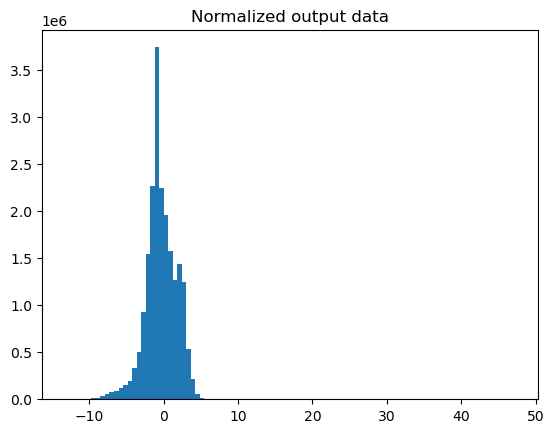

In [93]:
plt.hist(y_test_norm.flatten(), bins=100)
plt.title("Normalized output data")
#plt.hist(y_mse_test.flatten(), bins=10)
#plt.hist(y_dist_test.flatten(), bins=10)
plt.show()

In [94]:
mu_real, sigma_real = np.mean(y_test_norm), np.std(y_test_norm)
mu_mse, sigma_mse = np.mean(y_mse_test), np.std(y_mse_test)
mu_dist, sigma_dist = np.mean(y_dist_test), np.std(y_dist_test)



In [95]:
mu_real, mu_mse, mu_dist

(np.float64(-0.35196832216689283),
 np.float32(-0.36175743),
 np.float32(-0.36169025))

In [96]:
sigma_real, sigma_mse, sigma_dist

(np.float64(2.084488076556322), np.float32(2.016912), np.float32(2.0150366))

Text(0.5, 1.0, 'MSE model on normalized input')

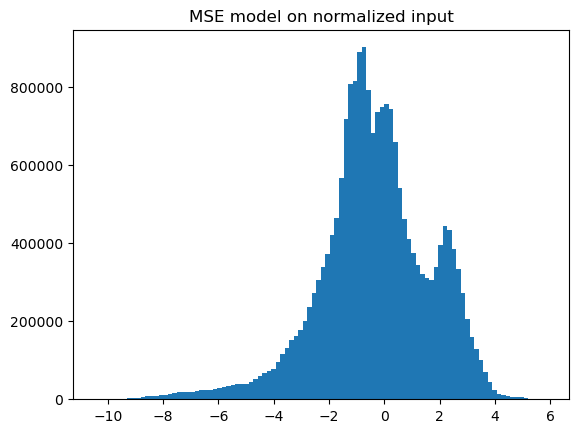

In [99]:
plt.hist(y_mse_test.flatten(), bins=100)
plt.title("MSE model on normalized input")

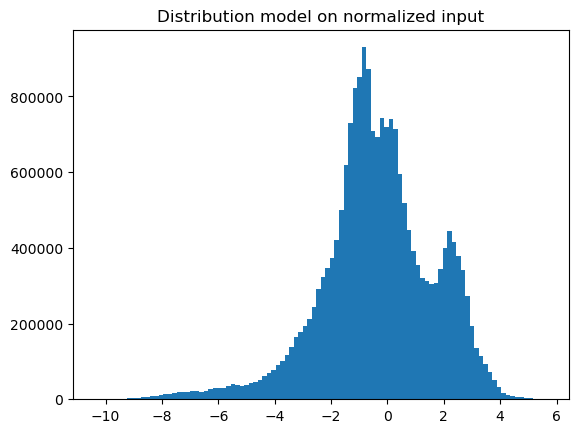

In [100]:
plt.hist(y_dist_test.flatten(), bins=100)
plt.title("Distribution model on normalized input")
plt.show()

In [65]:
dutils.input_scoring = x_test_norm
dutils.target_scoring = y_test_norm
# set pressure weights
dutils.set_pressure_grid(data_split = 'scoring')

# load model predictions
dutils.model_names = ['mse_model', 'dist_model']
predictions = {
    'mse_model' : y_mse_test, 
    'dist_model' : y_dist_test
}

dutils.preds_scoring = predictions

1. Undo output scaling

2. Weight vertical levels by dp/g
3. Weight horizontal area of each grid cell by a[x]/mean(a[x])
4. Convert units to a common energy unit

In [61]:
y_test

array([[2.11955523e+02, 2.22814364e+02, 2.29187058e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.09319429e+02, 2.21327028e+02, 2.28610102e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.18145683e+02, 2.29463219e+02, 2.36486204e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.23846468e+02, 2.31604638e+02, 2.35934344e+02, ...,
        4.35842573e-04, 4.60220406e+01, 3.35470072e+01],
       [2.26222575e+02, 2.39913993e+02, 2.41833158e+02, ...,
        1.83709516e+02, 1.26466997e+02, 7.37017160e+01],
       [2.23984718e+02, 2.46728271e+02, 2.47862872e+02, ...,
        6.94026290e+00, 6.12777178e+01, 4.75462976e+01]])

In [54]:
dutils.reweight_target(data_split = 'scoring')
dutils.reweight_preds(data_split = 'scoring')


In [56]:
dutils.target_vars

['state_t',
 'state_q0001',
 'cam_out_NETSW',
 'cam_out_FLWDS',
 'cam_out_PRECSC',
 'cam_out_PRECC',
 'cam_out_SOLS',
 'cam_out_SOLL',
 'cam_out_SOLSD',
 'cam_out_SOLLD']

In [59]:
dutils.preds_weighted_scoring

{'mse_model': {'ptend_t': array([[[ 3.12060897e+02, -4.58239002e+02, -1.60931285e+03, ...,
           -3.68976511e+09, -1.06955413e+10, -8.23473956e+09],
          [ 3.51314176e+02, -5.17108946e+02, -1.81598226e+03, ...,
           -4.22617983e+09, -1.21845763e+10, -9.39267819e+09],
          [ 3.43838252e+02, -5.02598156e+02, -1.76665485e+03, ...,
           -3.93284564e+09, -1.14965178e+10, -8.83419609e+09],
          ...,
          [ 3.20966104e+02, -5.02227032e+02, -1.72303777e+03, ...,
           -3.49281941e+09, -1.02881298e+10, -7.98506819e+09],
          [ 3.37911252e+02, -5.14463074e+02, -1.78252651e+03, ...,
           -3.91443995e+09, -1.13605104e+10, -8.81082609e+09],
          [ 3.01597252e+02, -4.64552554e+02, -1.60361090e+03, ...,
           -3.46086240e+09, -1.01110619e+10, -7.85837988e+09]],
  
         [[ 3.12039292e+02, -4.58175726e+02, -1.60909554e+03, ...,
           -3.68905789e+09, -1.06935925e+10, -8.23325932e+09],
          [ 3.51273425e+02, -5.16985364e+02, -1

In [55]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2']
dutils.create_metrics_df(data_split = 'scoring')

KeyError: 'state_t'